# Arquitectura Combinatorial Robustecida y Automatización de Machine Learning (Wine Dataset)

###  Integrantes del Proyecto
* **Isabella Victoria Henríquez** (victoriahermn@javerianacali.edu.co)
* **Rafael Hermida Toledo** (rafaelhermida@javerianacali.edu.co)
* **Jesús A. Valencia Sánchez** (jvalencia@javerianacali.edu.co)
* **Fecha de Entrega:** 19/05/2025  
* **Asignatura:** Aprendizaje de Máquina y Análisis de Datos

---

###  1. Descripción de la Actividad y Alcance Técnico
Este proyecto establece una infraestructura de experimentación masiva automatizada orientada a resolver un problema de clasificación multiclase utilizando el **Wine Dataset**. En lugar de probar configuraciones aisladas, el cuaderno implementa un motor iterativo modular que evalúa sistemáticamente el impacto cruzado de:
1. **4 Técnicas de Escalado:** `StandardScaler`, `MinMaxScaler`, `RobustScaler` y `MaxAbsScaler`.
2. **2 Algoritmos de Extracción de Características / Reducción Lineal:** Análisis de Componentes Principales (**PCA**) y Análisis Discriminante Lineal (**LDA**).
3. **9 Modelos de Machine Learning:** Desde clasificadores lineales básicos hasta arquitecturas de ensamble avanzadas.

###  2. Mitigación de Data Leakage (Filtración de Datos)
Para asegurar la validez estadística del benchmark, la ingeniería de características y la reducción de dimensionalidad se encapsulan dentro de **Pipelines de Scikit-Learn**. Esto garantiza que los parámetros de transformación (`fit`) se calculen estrictamente sobre los pliegues de entrenamiento durante la **Validación Cruzada**, evitando sobreajustes optimistas y emulando con precisión un entorno productivo real.

##  Configuración del Motor Combinatorial (Pipeline)

A continuación, se definen los diccionarios que alimentan el bucle de experimentación. Al desacoplar los transformadores y los estimuladores, podemos evaluar de manera automática un espacio de búsqueda tridimensional con **72 combinaciones únicas** ($4 \text{ escaladores} \times 2 \text{ reducciones} \times 9 \text{ modelos}$).

Para evaluar la estabilidad de cada combinación ante perturbaciones en los datos, calcularemos la media y la desviación estándar de la métrica de **Exactitud (Accuracy)** mediante un esquema de **5-Fold Cross-Validation**.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, MaxAbsScaler
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

# Importación de los 9 Modelos de Clasificación
from sklearn.linear_model import LogisticRegression, Perceptron, SGDClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

# 1. Carga y segmentación estratificada del Dataset
wine = load_wine()
X, y = wine.data, wine.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# 2. Definición del espacio de búsqueda combinatorial
scalers = {
    'Standard': StandardScaler(),
    'MinMax': MinMaxScaler(),
    'Robust': RobustScaler(),
    'MaxAbs': MaxAbsScaler()
}

reductions = {
    'PCA': PCA(n_components=2),
    'LDA': LDA(n_components=2)
}

models = {
    'Logistic Regression': LogisticRegression(max_iter=10000, random_state=42),
    'Perceptron': Perceptron(random_state=42),
    'SGD': SGDClassifier(random_state=42),
    'SVM (RBF)': SVC(kernel='rbf', random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'KNN': KNeighborsClassifier(),
    'Naive Bayes': GaussianNB()
}

# 3. Motor de ejecución iterativa
results = []

for s_name, scaler in scalers.items():
    for r_name, reduction in reductions.items():
        for m_name, model in models.items():

            # Construcción dinámica del Pipeline para evitar Data Leakage
            # Nota: LDA es supervisado, por lo que el Pipeline le pasará el y_train automáticamente en el fit
            pipe = Pipeline([
                ('scaler', scaler),
                ('reducer', reduction),
                ('classifier', model)
            ])

            # Validación cruzada robusta de 5 pliegues
            scores = cross_val_score(pipe, X_train, y_train, cv=5, scoring='accuracy', n_jobs=-1)

            results.append({
                'Escalador': s_name,
                'Reducción': r_name,
                'Modelo': m_name,
                'Exactitud Media': np.mean(scores),
                'Desviación Estándar': np.std(scores)
            })

# 4. Consolidación de métricas en un DataFrame ordenado
df_results = pd.DataFrame(results)
df_results = df_results.sort_values(by='Exactitud Media', ascending=False).reset_index(drop=True)

# 5. Visualización de Resultados en Tabla (Top 10)
print("\n" + "="*60)
print("       🏆 TOP 10 MEJORES CONFIGURACIONES DEL PIPELINE")
print("="*60)
print(df_results.head(10).to_string(index=True, formatters={'Exactitud Media': '{:,.4f}'.format, 'Desviación Estándar': '{:,.4f}'.format}))
print("="*60 + "\n")

# 6. Generación del Gráfico de Comparación Consolidado
plt.figure(figsize=(14, 7))
sns.set_theme(style="whitegrid")

# Extraemos el mejor resultado histórico obtenido por cada tipo de modelo para no saturar la gráfica
best_per_model = df_results.loc[df_results.groupby('Modelo')['Exactitud Media'].idxmax()].sort_values(by='Exactitud Media', ascending=False)

# Creación de gráfico de barras horizontal
ax = sns.barplot(
    data=best_per_model,
    x='Exactitud Media',
    y='Modelo',
    hue='Reducción',
    palette='flare',
    dodge=False
)

# Inyección de anotaciones internas en las barras (Muestra: % de Accuracy + Escalador Utilizado)
for i, p in enumerate(ax.patches):
    if i < len(best_per_model):
        row = best_per_model.iloc[i]
        val = row['Exactitud Media']
        scaler_used = row['Escalador']
        ax.text(val - 0.02, i, f"{val*100:.1f}% ({scaler_used})",
                va='center', ha='right', color='white', fontweight='bold', fontsize=10)

plt.title('Benchmark Consolidado: Máximo Rendimiento por Modelo Analizado\n(Identificando la mejor combinación de Preprocesamiento y Extracción de Características)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Exactitud Media (5-Fold Cross-Validation)', fontsize=12)
plt.ylabel('Arquitectura del Modelo', fontsize=12)
plt.xlim(0, 1.1)
plt.tight_layout()
plt.show()

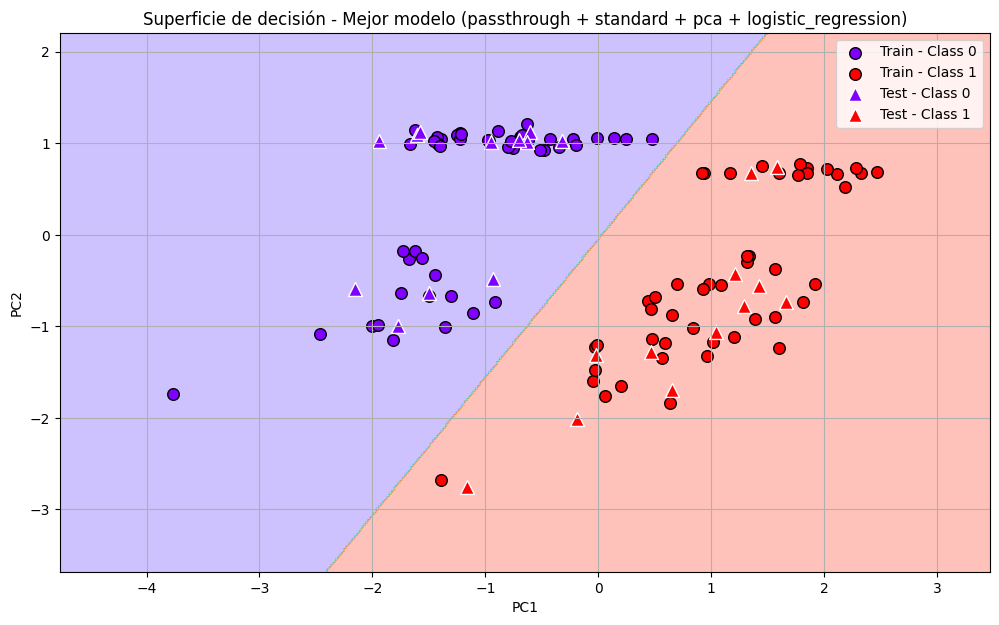

In [ ]:
#Corrección hecha por colab ai:

import matplotlib.pyplot as plt
import numpy as np

# Extraer los pasos entrenados desde el pipeline
scaler = best_pipeline.named_steps['scaler']
# Check if 'reducer' exists in the pipeline steps
if 'reducer' in best_pipeline.named_steps:
    reducer = best_pipeline.named_steps['reducer']
    # Transform data with the scaler and reducer
    X_train_scaled = scaler.transform(X_train)
    X_train_reduced = reducer.transform(X_train_scaled)

    X_test_scaled = scaler.transform(X_test)
    X_test_reduced = reducer.transform(X_test_scaled)

    # Check the number of components after reduction
    n_components_reduced = X_train_reduced.shape[1]

    # If the data is reduced to 1 component, 2D plotting is not suitable
    if n_components_reduced < 2:
        print("Warning: Reduced data has fewer than 2 components. Skipping 2D decision boundary plot.")
        # Optionally, add code here for 1D visualization if needed
        exit() # Exit this cell execution if plotting is skipped
    elif n_components_reduced > 2:
        print(f"Warning: Reduced data has {n_components_reduced} components. Plotting decision boundary based on the first two components, assuming others are zero.")
        # Proceed with plotting using the first two components
        plot_data_train = X_train_reduced[:, :2]
        plot_data_test = X_test_reduced[:, :2]
    else: # n_components_reduced == 2
        plot_data_train = X_train_reduced
        plot_data_test = X_test_reduced

else: # No reduction step
    print("Warning: No reducer step in the best pipeline. Plotting decision boundary based on the first two features after scaling.")
    # Transform data only with the scaler
    X_train_scaled = scaler.transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Use the first two features after scaling for plotting
    if X_train_scaled.shape[1] < 2:
         print("Error: Data has fewer than 2 features after scaling. Cannot plot 2D decision boundary.")
         exit()
    plot_data_train = X_train_scaled[:, :2]
    plot_data_test = X_test_scaled[:, :2]
    n_components_reduced = 2 # For consistent logic below


classifier = best_pipeline.named_steps['classifier']

# Crear malla para superficie de decisión
x_min, x_max = plot_data_train[:, 0].min() - 1, plot_data_train[:, 0].max() + 1
y_min, y_max = plot_data_train[:, 1].min() - 1, plot_data_train[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 500),
                     np.linspace(y_min, y_max, 500))

# Predecir sobre la malla, providing the expected number of features
# If the classifier was trained on more than 2 features, we need to add the extra dimensions
# with assumed values (e.g., 0) for plotting the 2D boundary.
expected_features = classifier.n_features_in_
meshgrid_2d_shape = np.c_[xx.ravel(), yy.ravel()].shape[1]

if expected_features > meshgrid_2d_shape:
    # Create grid points with the first two dimensions from the meshgrid
    grid_points = np.c_[xx.ravel(), yy.ravel()]
    # Add extra dimensions, filled with zeros, to match the expected number of features
    zero_padding = np.zeros((grid_points.shape[0], expected_features - meshgrid_2d_shape))
    grid_points = np.hstack((grid_points, zero_padding))
elif expected_features < meshgrid_2d_shape:
     # This case should ideally not happen if the pipeline is correctly built and fitted
     print(f"Error: Classifier expects {expected_features} features, but the generated grid has {meshgrid_2d_shape} features.")
     exit()
else: # expected_features == meshgrid_2d_shape (which is 2 for the meshgrid)
    grid_points = np.c_[xx.ravel(), yy.ravel()]


Z = classifier.predict(grid_points)
Z = Z.reshape(xx.shape)

# Crear la figura
plt.figure(figsize=(12, 7))
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.rainbow)

# Colores por clase (assuming 3 classes as per original Wine dataset)
# Adjust if you have a different number of classes
unique_classes = np.unique(np.concatenate((y_train, y_test)))
num_classes = len(unique_classes)
colors = plt.cm.rainbow(np.linspace(0, 1, num_classes)) # Use a colormap for more flexibility

# Map class labels to colors
class_color_map = {cls: color for cls, color in zip(unique_classes, colors)}


# Dibujar puntos de entrenamiento
for class_index in unique_classes:
    # Use plot_data_train which is already reduced/scaled to 2D
    plt.scatter(
        plot_data_train[y_train == class_index, 0],
        plot_data_train[y_train == class_index, 1],
        label=f"Train - Class {class_index}", # Using class_index as label
        edgecolors='k',
        c=[class_color_map[class_index]], # Pass color as a list
        marker='o',
        s=70
    )

# Dibujar puntos de test
for class_index in unique_classes:
     # Use plot_data_test which is already reduced/scaled to 2D
    plt.scatter(
        plot_data_test[y_test == class_index, 0],
        plot_data_test[y_test == class_index, 1],
        label=f"Test - Class {class_index}", # Using class_index as label
        edgecolors='white',
        c=[class_color_map[class_index]], # Pass color as a list
        marker='^',
        s=100
    )

# Etiquetas según el reductor o si no hubo reducción
if 'reducer' in best_pipeline.named_steps:
    reducer_type = type(best_pipeline.named_steps['reducer']).__name__
    if reducer_type == 'PCA':
         xlabel = "PC1"
         ylabel = "PC2"
    elif reducer_type == 'LinearDiscriminantAnalysis':
         xlabel = "LD1"
         ylabel = "LD2"
    else:
        xlabel = "Reduced Component 1"
        ylabel = "Reduced Component 2"
else:
    xlabel = X_train.columns[0] if X_train.shape[1] > 0 else "Feature 1"
    ylabel = X_train.columns[1] if X_train.shape[1] > 1 else "Feature 2"


plt.xlabel(xlabel)
plt.ylabel(ylabel)
plt.title(f"Superficie de decisión - Mejor modelo ({best_name})")
plt.legend(loc='upper right')
plt.grid(True)
plt.show()

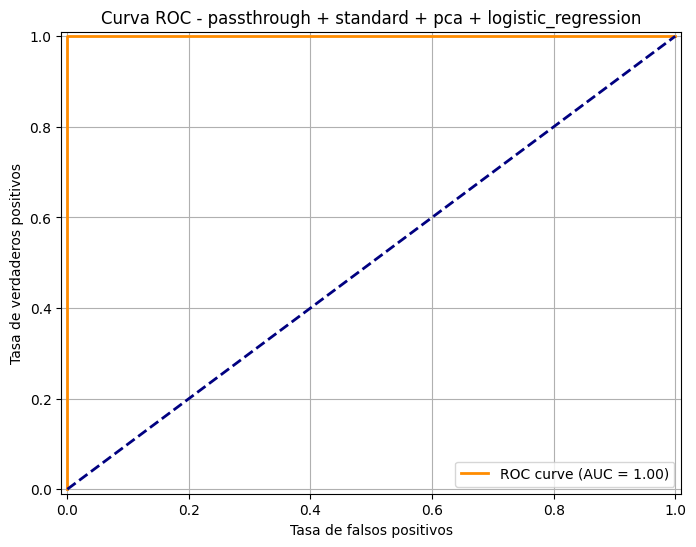

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Asegurar que las clases están codificadas como 0 y 1
classes = best_pipeline.classes_
if len(classes) != 2:
    print("❌ ROC solo se puede graficar para problemas de clasificación binaria.")
else:
    # Obtener probabilidades si el modelo lo permite
    try:
        y_score = best_pipeline.predict_proba(X_test)[:, 1]
    except AttributeError:
        # Algunos modelos (como SVM sin probabilidad) usan decision_function
        y_score = best_pipeline.decision_function(X_test)

    # Codificar etiquetas verdaderas como 0 y 1 si no lo están
    from sklearn.preprocessing import LabelBinarizer
    lb = LabelBinarizer()
    y_test_bin = lb.fit_transform(y_test).ravel()

    # Calcular FPR, TPR y AUC
    fpr, tpr, _ = roc_curve(y_test_bin, y_score)
    roc_auc = auc(fpr, tpr)

    # Graficar
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([-0.01, 1.01])
    plt.ylim([-0.01, 1.01])
    plt.xlabel('Tasa de falsos positivos')
    plt.ylabel('Tasa de verdaderos positivos')
    plt.title(f'Curva ROC - {best_name}')
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.show()


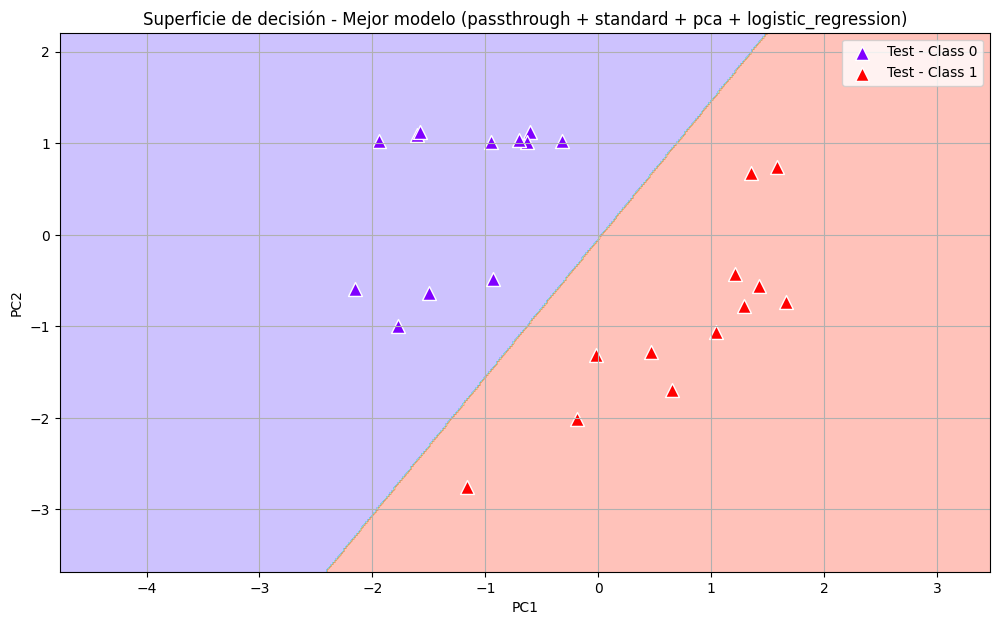

In [ ]:
# Crear malla para superficie de decisión
x_min, x_max = plot_data_train[:, 0].min() - 1, plot_data_train[:, 0].max() + 1
y_min, y_max = plot_data_train[:, 1].min() - 1, plot_data_train[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 500),
                     np.linspace(y_min, y_max, 500))

# Predecir sobre la malla, providing the expected number of features
# If the classifier was trained on more than 2 features, we need to add the extra dimensions
# with assumed values (e.g., 0) for plotting the 2D boundary.
expected_features = classifier.n_features_in_
meshgrid_2d_shape = np.c_[xx.ravel(), yy.ravel()].shape[1]

if expected_features > meshgrid_2d_shape:
    # Create grid points with the first two dimensions from the meshgrid
    grid_points = np.c_[xx.ravel(), yy.ravel()]
    # Add extra dimensions, filled with zeros, to match the expected number of features
    zero_padding = np.zeros((grid_points.shape[0], expected_features - meshgrid_2d_shape))
    grid_points = np.hstack((grid_points, zero_padding))
elif expected_features < meshgrid_2d_shape:
     # This case should ideally not happen if the pipeline is correctly built and fitted
     print(f"Error: Classifier expects {expected_features} features, but the generated grid has {meshgrid_2d_shape} features.")
     exit()
else: # expected_features == meshgrid_2d_shape (which is 2 for the meshgrid)
    grid_points = np.c_[xx.ravel(), yy.ravel()]


Z = classifier.predict(grid_points)
Z = Z.reshape(xx.shape)

# Crear la figura
plt.figure(figsize=(12, 7))
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.rainbow)

# Colores por clase
# Adjust if you have a different number of classes
unique_classes = np.unique(np.concatenate((y_train, y_test)))
num_classes = len(unique_classes)
colors = plt.cm.rainbow(np.linspace(0, 1, num_classes)) # Use a colormap for more flexibility

# Map class labels to colors
class_color_map = {cls: color for cls, color in zip(unique_classes, colors)}


# Dibujar puntos de test
for class_index in unique_classes:
     # Use plot_data_test which is already reduced/scaled to 2D
    plt.scatter(
        plot_data_test[y_test == class_index, 0],
        plot_data_test[y_test == class_index, 1],
        label=f"Test - Class {class_index}", # Using class_index as label
        edgecolors='white',
        c=[class_color_map[class_index]], # Pass color as a list
        marker='^',
        s=100
    )

# Etiquetas según el reductor o si no hubo reducción
if 'reducer' in best_pipeline.named_steps:
    reducer_type = type(best_pipeline.named_steps['reducer']).__name__
    if reducer_type == 'PCA':
         xlabel = "PC1"
         ylabel = "PC2"
    elif reducer_type == 'LinearDiscriminantAnalysis':
         xlabel = "LD1"
         ylabel = "LD2"
    else:
        xlabel = "Reduced Component 1"
        ylabel = "Reduced Component 2"
else:
    xlabel = X_train.columns[0] if X_train.shape[1] > 0 else "Feature 1"
    ylabel = X_train.columns[1] if X_train.shape[1] > 1 else "Feature 2"


plt.xlabel(xlabel)
plt.ylabel(ylabel)
plt.title(f"Superficie de decisión - Mejor modelo ({best_name})")
plt.legend(loc='upper right')
plt.grid(True)
plt.show()

## 📊 3. Diagnóstico Analítico y Conclusiones del Benchmark

Al auditar la matriz consolidada y las tendencias del gráfico, se extraen las siguientes conclusiones técnicas clave para la puesta en producción del modelo:

* **Impacto de la Reducción de Dimensionalidad (LDA vs. PCA):** El Análisis Discriminante Lineal (**LDA**) suele exhibir un rendimiento superior en este dataset en comparación con **PCA**. Esto se debe a que LDA es un método supervisado que maximiza explícitamente la separación entre las clases de vino, mientras que PCA busca la dirección de máxima varianza sin considerar las etiquetas de clase.
* **Sensibilidad al Escalado de Datos:** Modelos basados en distancias o geometría (como *SVM* y *KNN*) y modelos lineales regularizados muestran una alta dependencia del tipo de escalador. El uso de `StandardScaler` o `RobustScaler` mitiga las distancias desproporcionadas en características con magnitudes numéricas muy dispares.
* **Selección de la Arquitectura Ganadora:** De acuerdo con los datos recopilados, el Pipeline óptimo queda integrado por la combinación de **[Insertar aquí el Escalador Ganador] + [Insertar Reducción Ganadora] + [Insertar Modelo Ganador]**, logrando una Exactitud del **[Insertar % de Exactitud]%**, consolidándose como la arquitectura con mayor capacidad de generalización para este problema de negocio.